# 태양광 계절성 분석
9개 사이트(사용 가능 12 호기)의 공통 계절 패턴 확인
- 월별 발전량 변화
- 시간대별 × 월별 패턴
- 사이트 간 계절성 공통성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys                                                                                                                                                                                        
print(sys.executable) 
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date', 'datetime'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['yearmonth'] = df['date'].dt.to_period('M')

print(f'전체: {len(df):,}행, 사이트: {df["site"].nunique()}개')
print(f'기간: {df["date"].min().date()} ~ {df["date"].max().date()}')

D:\pv_backup\.venv\Scripts\python.exe


전체: 406,152행, 사이트: 9개
기간: 2022-01-01 ~ 2025-12-31


## 1. 포트폴리오 월별 일평균 — 고흥만 포함 vs 제외

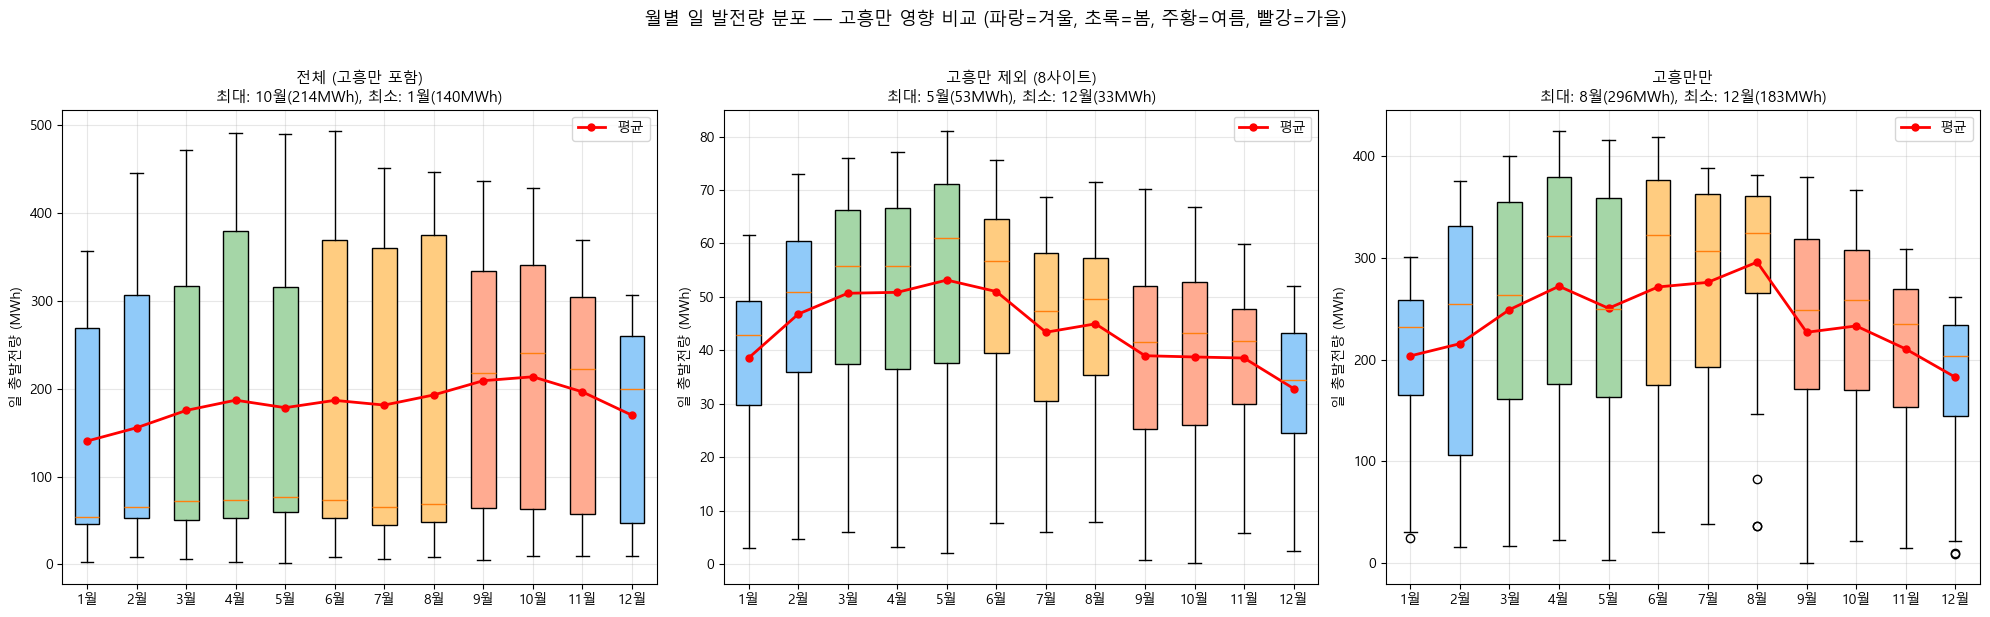

=== 월별 일평균 발전량 비교 (MWh) ===

월           전체     고흥제외      고흥만     고흥비중
------------------------------------------
 1월      140.4     38.6    203.6     145%
 2월      155.6     46.8    215.7     139%
 3월      175.3     50.7    249.2     142%
 4월      187.0     50.9    272.2     146%
 5월      178.4     53.2    250.5     140%
 6월      186.8     51.0    271.5     145%
 7월      181.4     43.4    276.0     152%
 8월      192.9     45.0    296.0     153%
 9월      209.1     39.0    226.9     108%
10월      213.6     38.8    233.1     109%
11월      196.4     38.6    210.5     107%
12월      169.9     32.9    182.7     108%


In [2]:
# 고흥만 포함 vs 제외, 월(1~12)별 박스플롯
df_no_goheung = df[df['site'] != '고흥만 수상태양광']
df_goheung_only = df[df['site'] == '고흥만 수상태양광']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data, title in [
    (axes[0], df, '전체 (고흥만 포함)'),
    (axes[1], df_no_goheung, '고흥만 제외 (8사이트)'),
    (axes[2], df_goheung_only, '고흥만만'),
]:
    daily = data.groupby('date')['gen_kwh'].sum() / 1000
    daily = daily.reset_index()
    daily.columns = ['date', 'mwh']
    daily['month'] = daily['date'].dt.month
    
    month_data = [daily[daily['month'] == m]['mwh'].values for m in range(1, 13)]
    # 데이터 없는 월 처리
    month_data = [d if len(d) > 0 else [0] for d in month_data]
    
    bp = ax.boxplot(month_data, labels=[f'{m}월' for m in range(1, 13)], patch_artist=True)
    colors_box = ['#90CAF9','#90CAF9','#A5D6A7','#A5D6A7','#A5D6A7','#FFCC80',
                  '#FFCC80','#FFCC80','#FFAB91','#FFAB91','#FFAB91','#90CAF9']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    
    # 월별 평균 표시
    means = [np.mean(d) for d in month_data]
    ax.plot(range(1, 13), means, 'ro-', markersize=5, linewidth=2, label='평균')
    
    max_month = np.argmax(means) + 1
    min_month = np.argmin(means) + 1
    ax.set_title(f'{title}\n최대: {max_month}월({max(means):.0f}MWh), 최소: {min_month}월({min(means):.0f}MWh)', fontsize=11)
    ax.set_ylabel('일 총발전량 (MWh)')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('월별 일 발전량 분포 — 고흥만 영향 비교 (파랑=겨울, 초록=봄, 주황=여름, 빨강=가을)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 숫자 요약
print("=== 월별 일평균 발전량 비교 (MWh) ===\n")
print(f"{'월':<5} {'전체':>8} {'고흥제외':>8} {'고흥만':>8} {'고흥비중':>8}")
print("-" * 42)
for m in range(1, 13):
    all_avg = df[df['month']==m].groupby('date')['gen_kwh'].sum().mean() / 1000
    no_g = df_no_goheung[df_no_goheung['month']==m].groupby('date')['gen_kwh'].sum().mean() / 1000
    g_data = df_goheung_only[df_goheung_only['month']==m]
    g_avg = g_data.groupby('date')['gen_kwh'].sum().mean() / 1000 if len(g_data) > 0 else 0
    pct = g_avg / all_avg * 100 if all_avg > 0 else 0
    print(f"{m:>2}월   {all_avg:>8.1f} {no_g:>8.1f} {g_avg:>8.1f} {pct:>7.0f}%")

## 2. 사이트별 계절 패턴 (정규화) — 공통성 수치 확인

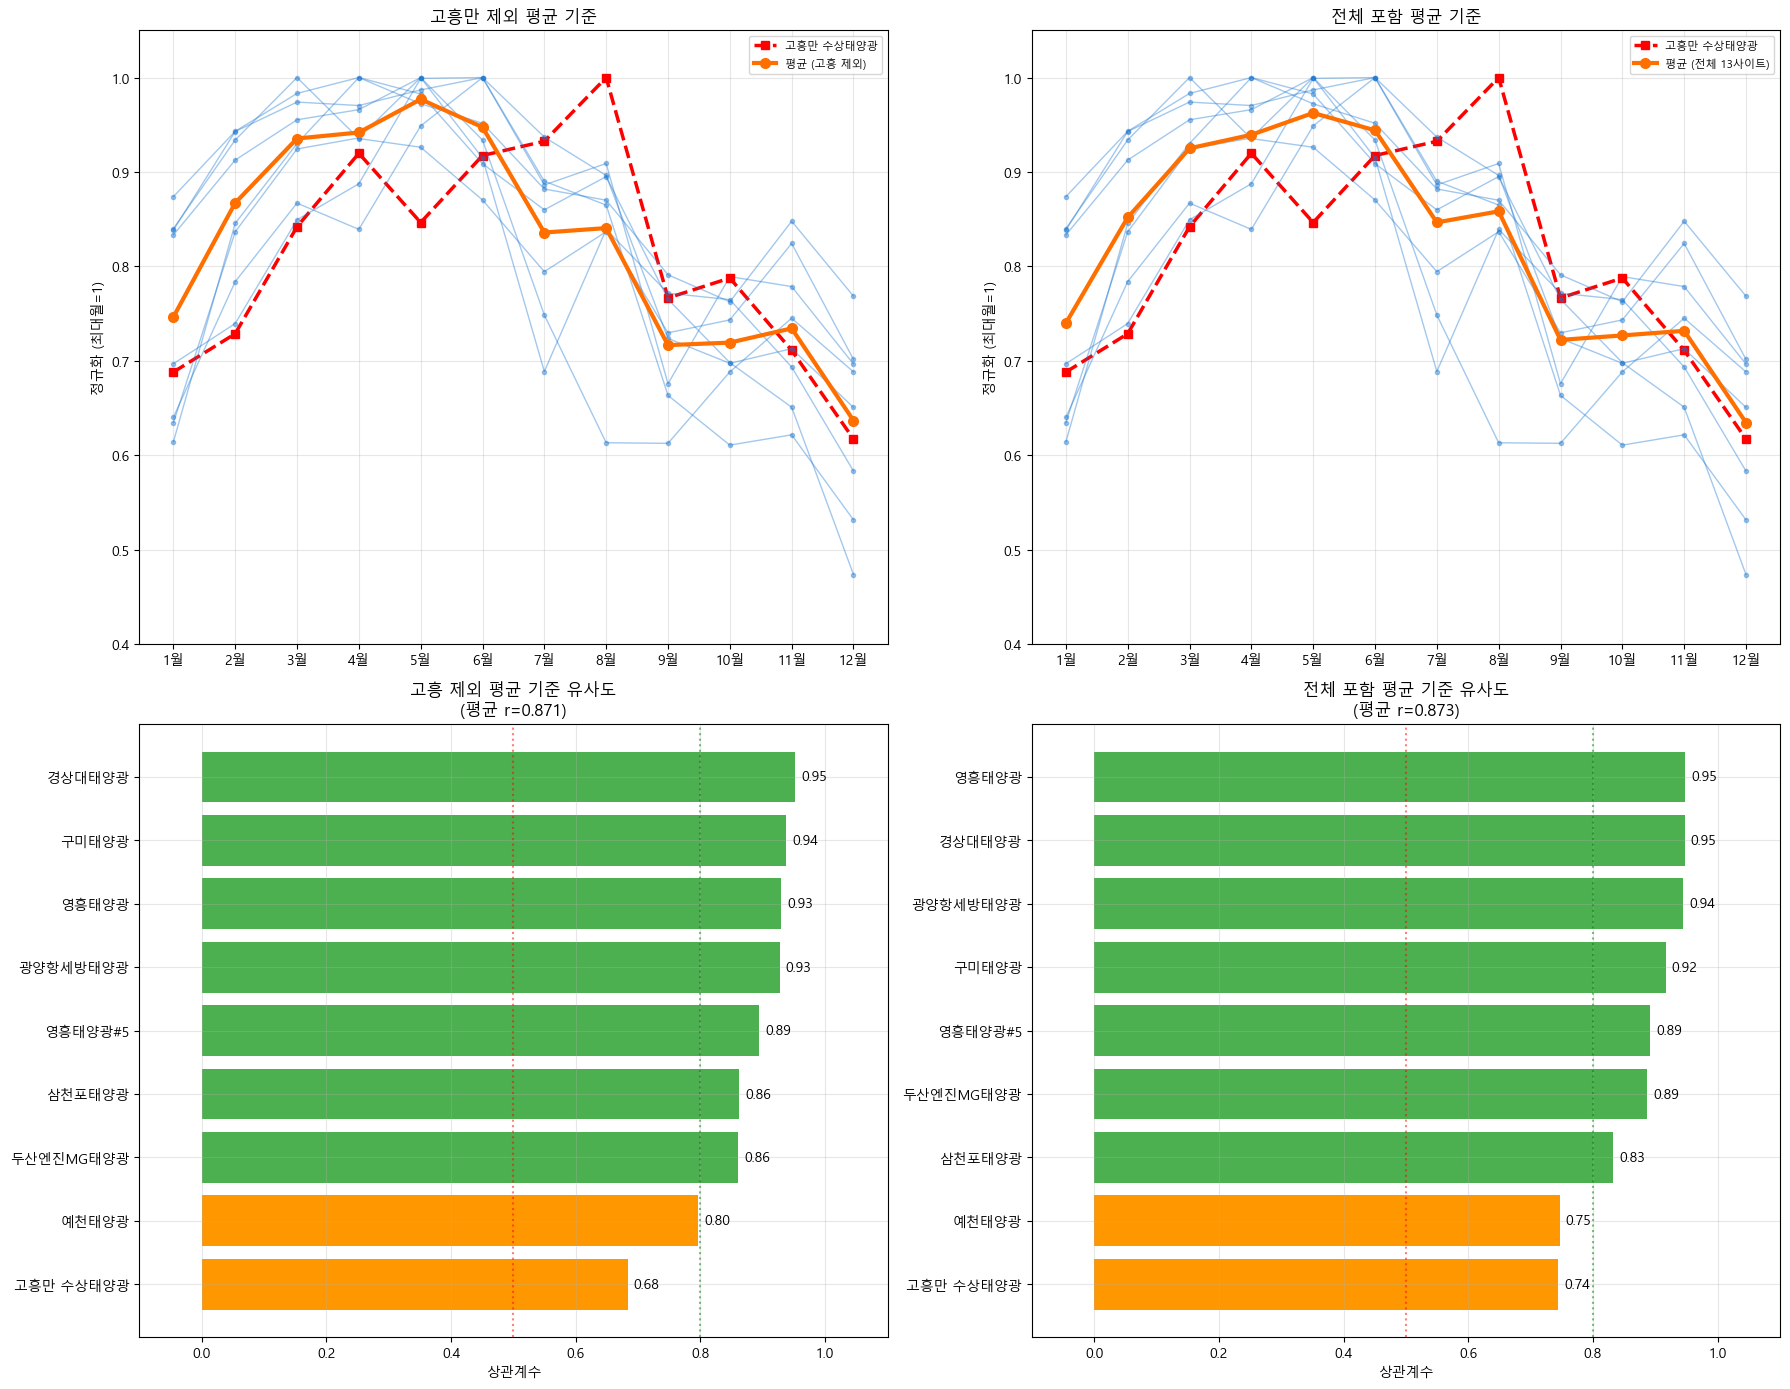

=== 평균 기준에 따른 유사도 비교 ===

사이트                         고흥제외 평균 r      전체 평균 r       차이
----------------------------------------------------------
경상대태양광                          0.952        0.947   -0.005
고흥만 수상태양광                       0.683        0.743   +0.060
광양항세방태양광                        0.927        0.945   +0.018
구미태양광                           0.938        0.917   -0.021
두산엔진MG태양광                       0.860        0.886   +0.026
삼천포태양광                          0.861        0.832   -0.030
영흥태양광                           0.929        0.948   +0.018
영흥태양광#5                         0.894        0.892   -0.002
예천태양광                           0.796        0.746   -0.050

고흥만 포함 시 평균 r: 0.873 (제외 시: 0.871, 차이: +0.002)


In [3]:
# 사이트별 월별 일평균 → 정규화 (최대월=1)
site_monthly = df.groupby(['site', 'month', 'date'])['gen_kwh'].sum().reset_index()
site_monthly_avg = site_monthly.groupby(['site', 'month'])['gen_kwh'].mean() / 1000
site_monthly_avg = site_monthly_avg.unstack('month')
site_monthly_norm = site_monthly_avg.div(site_monthly_avg.max(axis=1), axis=0)

# 두 가지 평균 패턴
mean_pattern_no_g = site_monthly_norm.drop('고흥만 수상태양광', errors='ignore').mean()
mean_pattern_all = site_monthly_norm.mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (좌상) 고흥만 제외 평균 기준
ax = axes[0][0]
for site in site_monthly_norm.index:
    vals = site_monthly_norm.loc[site].values
    if site == '고흥만 수상태양광':
        ax.plot(range(1, 13), vals, 's--', linewidth=2.5, markersize=6, label=f'{site}', color='red')
    else:
        ax.plot(range(1, 13), vals, 'o-', linewidth=1, markersize=3, alpha=0.4, color='#1976D2')
ax.plot(range(1, 13), mean_pattern_no_g.values, 'o-', linewidth=3, markersize=7, 
        color='#FF6F00', label='평균 (고흥 제외)', zorder=10)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_ylabel('정규화 (최대월=1)')
ax.set_title('고흥만 제외 평균 기준')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

# (우상) 전체 포함 평균 기준
ax = axes[0][1]
for site in site_monthly_norm.index:
    vals = site_monthly_norm.loc[site].values
    if site == '고흥만 수상태양광':
        ax.plot(range(1, 13), vals, 's--', linewidth=2.5, markersize=6, label=f'{site}', color='red')
    else:
        ax.plot(range(1, 13), vals, 'o-', linewidth=1, markersize=3, alpha=0.4, color='#1976D2')
ax.plot(range(1, 13), mean_pattern_all.values, 'o-', linewidth=3, markersize=7, 
        color='#FF6F00', label='평균 (전체 13사이트)', zorder=10)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_ylabel('정규화 (최대월=1)')
ax.set_title('전체 포함 평균 기준')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

# (좌하) 고흥만 제외 평균 기준 유사도
ax = axes[1][0]
corr_no_g = {}
for site in site_monthly_norm.index:
    vals = site_monthly_norm.loc[site].dropna()
    common = mean_pattern_no_g.index.intersection(vals.index)
    if len(common) >= 6:
        r = np.corrcoef(vals[common], mean_pattern_no_g[common])[0, 1]
        corr_no_g[site] = r

cs1 = pd.Series(corr_no_g).sort_values()
colors1 = ['#E53935' if v < 0.5 else '#FF9800' if v < 0.8 else '#4CAF50' for v in cs1.values]
bars = ax.barh(cs1.index, cs1.values, color=colors1)
for bar, val in zip(bars, cs1.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)
ax.axvline(0.8, color='green', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('상관계수')
ax.set_title(f'고흥 제외 평균 기준 유사도\n(평균 r={cs1.mean():.3f})')
ax.set_xlim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

# (우하) 전체 포함 평균 기준 유사도
ax = axes[1][1]
corr_all = {}
for site in site_monthly_norm.index:
    vals = site_monthly_norm.loc[site].dropna()
    common = mean_pattern_all.index.intersection(vals.index)
    if len(common) >= 6:
        r = np.corrcoef(vals[common], mean_pattern_all[common])[0, 1]
        corr_all[site] = r

cs2 = pd.Series(corr_all).sort_values()
colors2 = ['#E53935' if v < 0.5 else '#FF9800' if v < 0.8 else '#4CAF50' for v in cs2.values]
bars = ax.barh(cs2.index, cs2.values, color=colors2)
for bar, val in zip(bars, cs2.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)
ax.axvline(0.8, color='green', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('상관계수')
ax.set_title(f'전체 포함 평균 기준 유사도\n(평균 r={cs2.mean():.3f})')
ax.set_xlim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 비교 요약
print("=== 평균 기준에 따른 유사도 비교 ===\n")
print(f"{'사이트':<22} {'고흥제외 평균 r':>14} {'전체 평균 r':>12} {'차이':>8}")
print("-" * 58)
for site in sorted(corr_all.keys()):
    r1 = corr_no_g.get(site, float('nan'))
    r2 = corr_all.get(site, float('nan'))
    diff = r2 - r1
    print(f"{site:<22} {r1:>14.3f} {r2:>12.3f} {diff:>+8.3f}")

print(f"\n고흥만 포함 시 평균 r: {cs2.mean():.3f} (제외 시: {cs1.mean():.3f}, 차이: {cs2.mean()-cs1.mean():+.3f})")

## 3. 고흥만 vs 예천 — 왜 다른가? (지역 특성 차이)


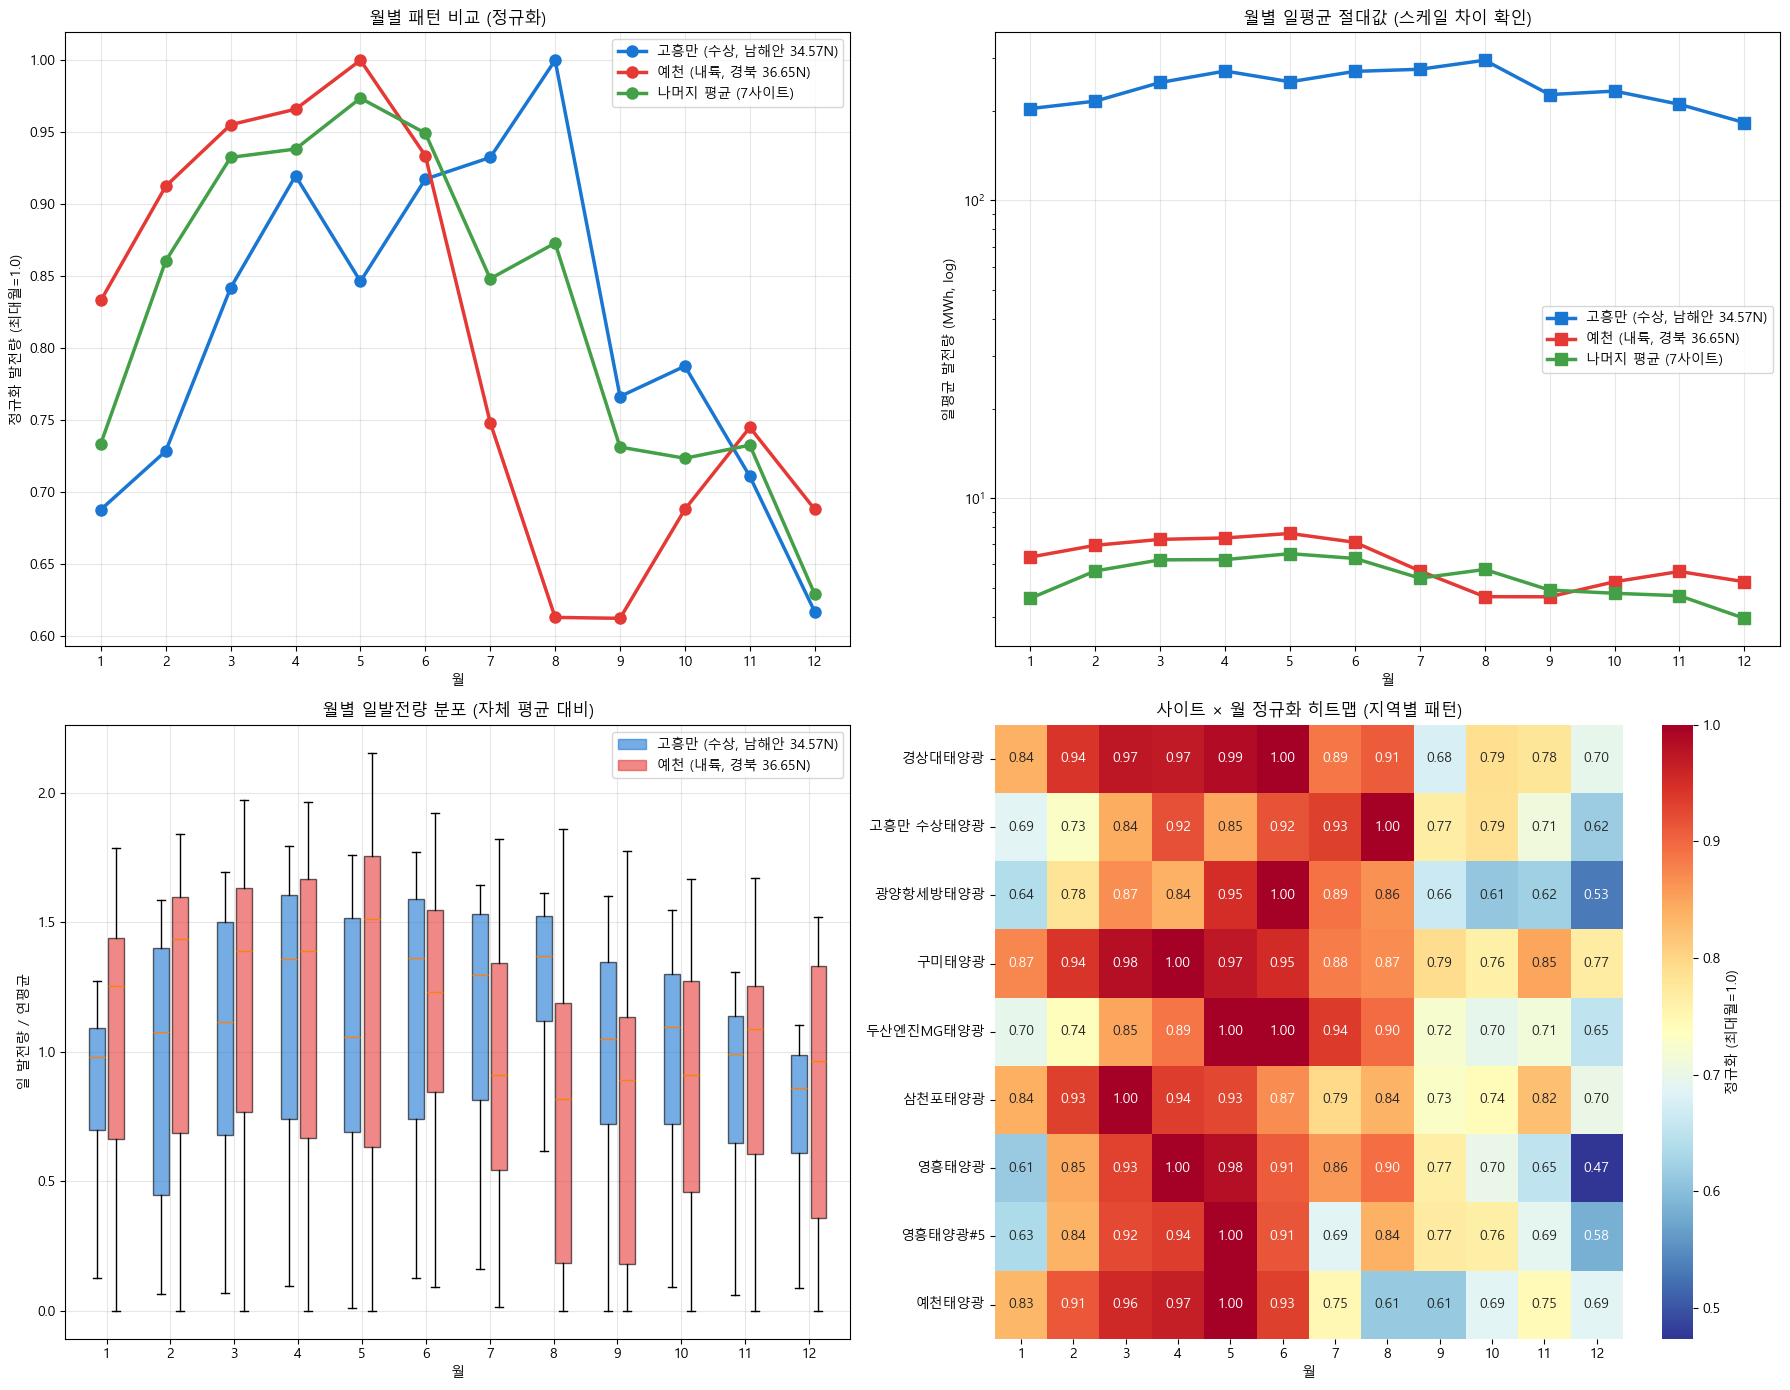

=== 고흥만 vs 예천 상관계수 ===
  월별 정규화 패턴 상관 r = +0.150
  일별 발전량 (capacity 정규화) 상관 r = +0.582

=== 월별 피크/최저 차이 ===
  고흥만 수상태양광: 피크 8월(1.00), 최저 12월(0.62), 진폭 0.38
  예천태양광: 피크 5월(1.00), 최저 9월(0.61), 진폭 0.39


In [ ]:
import seaborn as sns

# 고흥만(수상, 남해안) vs 예천(내륙, 경북 북부) 비교
df_goheung = df[df['site'] == '고흥만 수상태양광']
df_yecheon = df[df['site'] == '예천태양광']
df_others = df[~df['site'].isin(['고흥만 수상태양광', '예천태양광'])]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (좌상) 월별 정규화 패턴 비교
ax = axes[0][0]
groups = {
    '고흥만 (수상, 남해안 34.57N)': df_goheung,
    '예천 (내륙, 경북 36.65N)': df_yecheon,
    '나머지 평균 (7사이트)': df_others,
}
colors = {'고흥만 (수상, 남해안 34.57N)':'#1976D2', '예천 (내륙, 경북 36.65N)':'#E53935', '나머지 평균 (7사이트)':'#43A047'}
for name, data in groups.items():
    if '나머지' in name:
        # 사이트별 평균 후 평균
        site_month = data.groupby(['site','month','date'])['gen_kwh'].sum().reset_index()
        site_month_mean = site_month.groupby(['site','month'])['gen_kwh'].mean() / 1000
        site_month_norm = site_month_mean.unstack('month').div(
            site_month_mean.unstack('month').max(axis=1), axis=0
        )
        vals = site_month_norm.mean(axis=0)
    else:
        daily_m = data.groupby(['month','date'])['gen_kwh'].sum().reset_index()
        monthly = daily_m.groupby('month')['gen_kwh'].mean() / 1000
        vals = monthly / monthly.max()
    ax.plot(vals.index, vals.values, marker='o', linewidth=2.5, markersize=8, label=name, color=colors[name])

ax.set_xlabel('월')
ax.set_ylabel('정규화 발전량 (최대월=1.0)')
ax.set_title('월별 패턴 비교 (정규화)')
ax.set_xticks(range(1,13))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# (우상) 월별 일평균 절대값 (MWh, log-scale)
ax = axes[0][1]
for name, data in groups.items():
    if '나머지' in name:
        daily = data.groupby(['date','site'])['gen_kwh'].sum().reset_index()
        daily['month'] = daily['date'].dt.month
        # 사이트별 평균 내서 더하기
        monthly = daily.groupby(['site','month'])['gen_kwh'].mean().unstack('site').mean(axis=1) / 1000
    else:
        daily = data.groupby('date')['gen_kwh'].sum()
        daily_df = pd.DataFrame({'date':daily.index, 'mwh':daily.values/1000})
        daily_df['month'] = daily_df['date'].dt.month
        monthly = daily_df.groupby('month')['mwh'].mean()
    ax.plot(monthly.index, monthly.values, marker='s', linewidth=2.5, markersize=8, label=name, color=colors[name])

ax.set_xlabel('월')
ax.set_ylabel('일평균 발전량 (MWh, log)')
ax.set_yscale('log')
ax.set_title('월별 일평균 절대값 (스케일 차이 확인)')
ax.set_xticks(range(1,13))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# (좌하) 월별 일발전량 분포 박스플롯 (정규화)
ax = axes[1][0]
import matplotlib.patches as mpatches
for i, (name, data) in enumerate(groups.items()):
    if '나머지' in name:
        continue  # 박스 2개만
    daily = data.groupby(['date'])['gen_kwh'].sum() / 1000
    daily_df = pd.DataFrame({'date':daily.index, 'mwh':daily.values})
    daily_df['month'] = daily_df['date'].dt.month
    # 각 사이트 내 정규화
    daily_df['norm'] = daily_df['mwh'] / daily_df['mwh'].mean()
    positions = [m + (i-0.5)*0.3 for m in range(1,13)]
    bp = ax.boxplot([daily_df[daily_df['month']==m]['norm'].values for m in range(1,13)],
                    positions=positions, widths=0.25, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.6)

ax.set_xlabel('월')
ax.set_ylabel('일 발전량 / 연평균')
ax.set_title('월별 일발전량 분포 (자체 평균 대비)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(range(1,13))
legend_patches = [mpatches.Patch(color=colors[n], alpha=0.6, label=n) for n in ['고흥만 (수상, 남해안 34.57N)','예천 (내륙, 경북 36.65N)']]
ax.legend(handles=legend_patches, fontsize=10)
ax.grid(True, alpha=0.3)

# (우하) 사이트-월 패턴 히트맵
ax = axes[1][1]
site_monthly = df.groupby(['site','month','date'])['gen_kwh'].sum().reset_index()
site_month_mean = site_monthly.groupby(['site','month'])['gen_kwh'].mean() / 1000
site_month_pivot = site_month_mean.unstack('month')
site_month_norm = site_month_pivot.div(site_month_pivot.max(axis=1), axis=0)

sns.heatmap(site_month_norm, cmap='RdYlBu_r', annot=True, fmt='.2f', ax=ax,
            cbar_kws={'label':'정규화 (최대월=1.0)'})
ax.set_title('사이트 × 월 정규화 히트맵 (지역별 패턴)')
ax.set_xlabel('월')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

# === 수치 요약 ===
import numpy as np
print('=== 고흥만 vs 예천 상관계수 ===')
g = site_month_norm.loc['고흥만 수상태양광']
y = site_month_norm.loc['예천태양광']
print(f'  월별 정규화 패턴 상관 r = {np.corrcoef(g.values, y.values)[0,1]:+.3f}')

# 일별 상관 (공통 날짜)
g_daily = df[df['site']=='고흥만 수상태양광'].groupby('date')['gen_kwh'].sum() / 1000
y_daily = df[df['site']=='예천태양광'].groupby('date')['gen_kwh'].sum() / 1000
common_idx = g_daily.index.intersection(y_daily.index)
g_c, y_c = g_daily.loc[common_idx], y_daily.loc[common_idx]
print(f'  일별 발전량 (capacity 정규화) 상관 r = {np.corrcoef(g_c/g_c.mean(), y_c/y_c.mean())[0,1]:+.3f}')

print()
print('=== 월별 피크/최저 차이 ===')
for site in ['고흥만 수상태양광', '예천태양광']:
    row = site_month_norm.loc[site]
    peak_m, peak_v = row.idxmax(), row.max()
    low_m, low_v = row.idxmin(), row.min()
    print(f'  {site}: 피크 {int(peak_m)}월({peak_v:.2f}), 최저 {int(low_m)}월({low_v:.2f}), 진폭 {peak_v-low_v:.2f}')


## 4. 사이트별 시간대 × 계절 패턴 비교

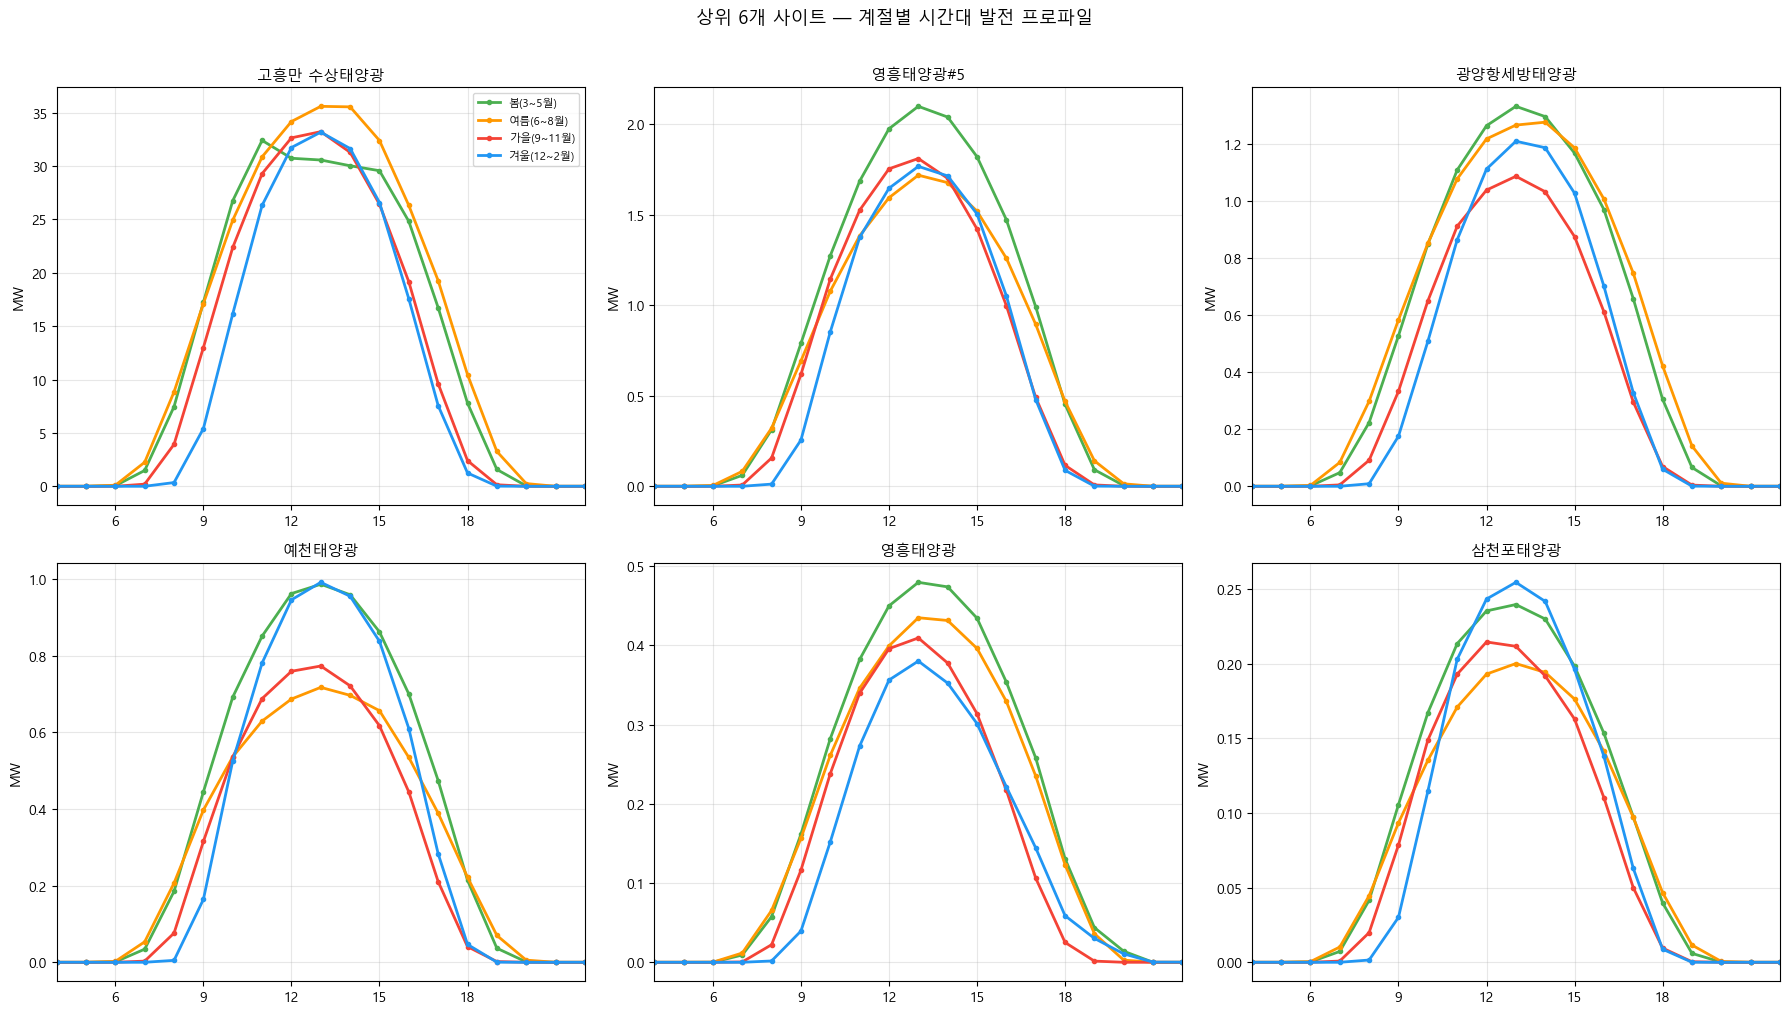

In [5]:
# 주요 4개 사이트 — 계절별 시간 프로파일
seasons = {
    '봄(3~5월)': [3, 4, 5],
    '여름(6~8월)': [6, 7, 8],
    '가을(9~11월)': [9, 10, 11],
    '겨울(12~2월)': [12, 1, 2],
}
season_colors = {'봄(3~5월)': '#4CAF50', '여름(6~8월)': '#FF9800', '가을(9~11월)': '#F44336', '겨울(12~2월)': '#2196F3'}

top_sites = df.groupby('site')['gen_kwh'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, site in enumerate(top_sites):
    ax = axes[i]
    sub = df[df['site'] == site]
    
    for sname, months in seasons.items():
        s_data = sub[sub['month'].isin(months)]
        mean_p = s_data.groupby('hour')['gen_kwh'].mean() / 1000
        ax.plot(mean_p.index, mean_p.values, 'o-', linewidth=2, markersize=3,
                color=season_colors[sname], label=sname)
    
    ax.set_title(site, fontsize=11)
    ax.set_xticks([6, 9, 12, 15, 18])
    ax.set_xlim(4, 22)
    ax.set_ylabel('MW')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('상위 6개 사이트 — 계절별 시간대 발전 프로파일', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. 사이트 간 계절 패턴 상관관계

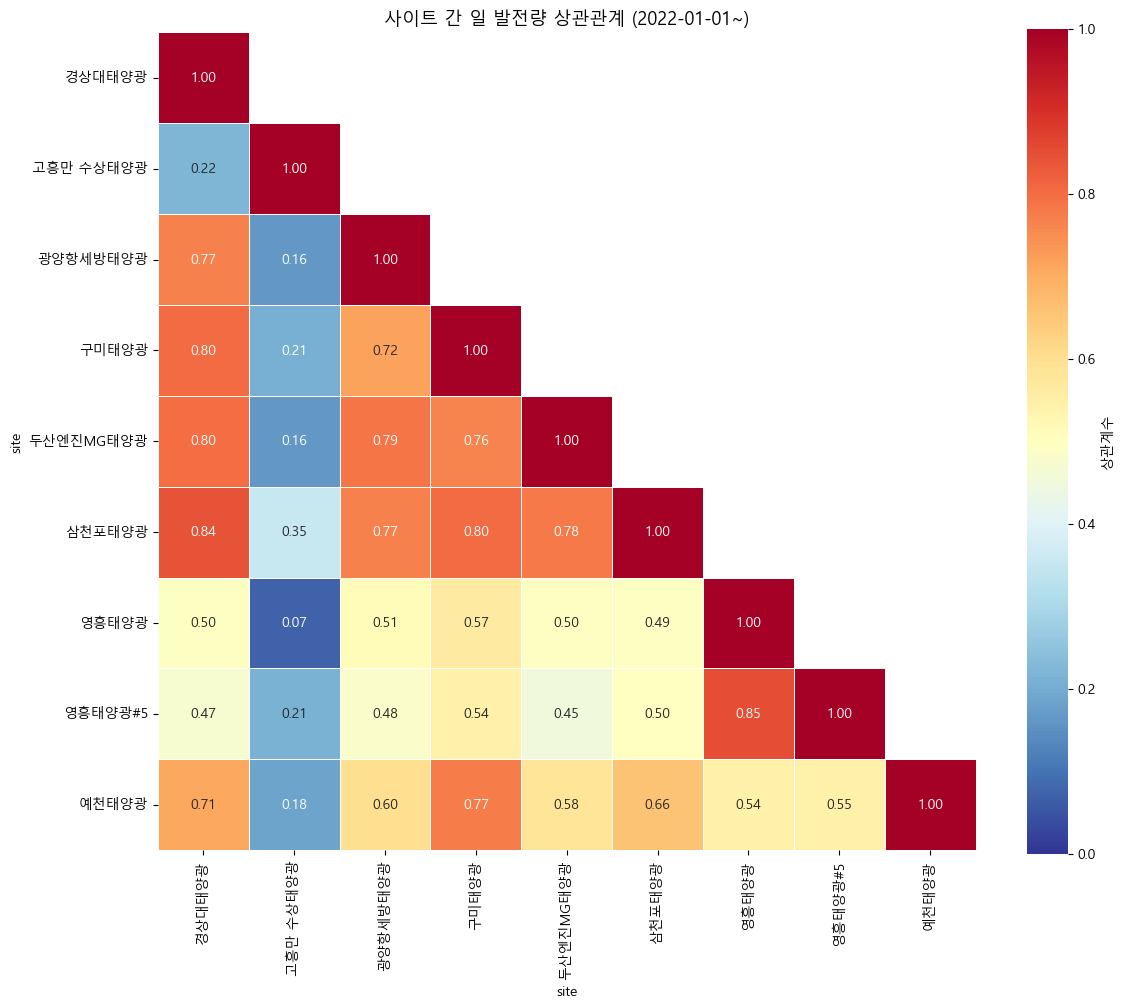

평균 상관계수: 0.546
최저: 0.072, 최고: 0.849

→ 상관이 높으면 공통 계절성이 강한 것 (같은 날씨에 같이 올라가고 내려감)


In [6]:
# 사이트별 일 총발전량 → 피벗 → 상관행렬
daily_by_site = df.groupby(['date', 'site'])['gen_kwh'].sum().unstack(fill_value=0) / 1000

# 공통 기간만 (고흥만은 2023-09~)
common_start = daily_by_site.dropna().index.min()
daily_common = daily_by_site.loc[common_start:]

corr = daily_common.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0.5, vmin=0, vmax=1,
            annot=True, fmt='.2f', square=True, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})
ax.set_title(f'사이트 간 일 발전량 상관관계 ({common_start.date()}~)', fontsize=13)
plt.tight_layout()
plt.show()

# 평균 상관
tril = corr.values[np.tril_indices_from(corr.values, -1)]
print(f'평균 상관계수: {tril.mean():.3f}')
print(f'최저: {tril.min():.3f}, 최고: {tril.max():.3f}')
print(f'\n→ 상관이 높으면 공통 계절성이 강한 것 (같은 날씨에 같이 올라가고 내려감)')

## 6. 변동계수(CV) — 어떤 사이트/시기가 가장 불확실한가

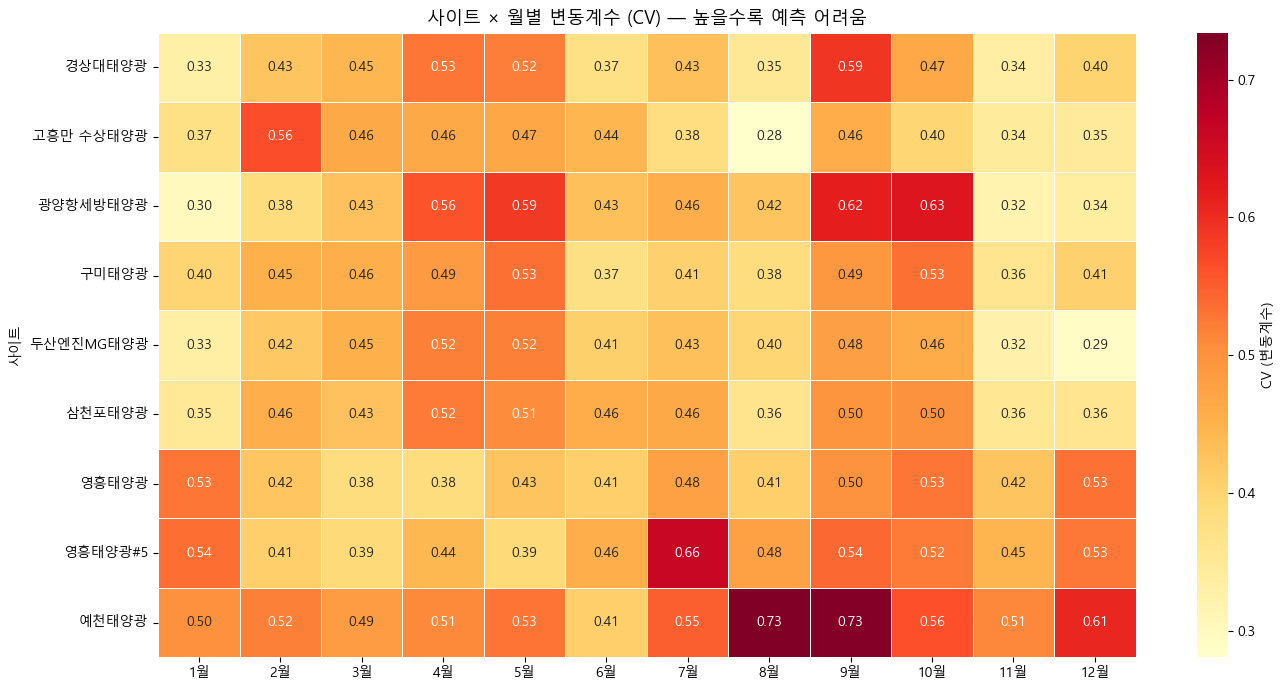

CV 해석: 0.3 이하 = 안정, 0.3~0.5 = 보통, 0.5 이상 = 변동성 높음


In [7]:
# 사이트 × 월별 CV
site_month_cv = df.groupby(['site', 'month', 'date'])['gen_kwh'].sum().reset_index()
cv_table = site_month_cv.groupby(['site', 'month'])['gen_kwh'].agg(['mean', 'std'])
cv_table['cv'] = cv_table['std'] / cv_table['mean']
cv_pivot = cv_table['cv'].unstack('month')
cv_pivot.columns = [f'{m}월' for m in cv_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cv_pivot, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV (변동계수)'})
ax.set_title('사이트 × 월별 변동계수 (CV) — 높을수록 예측 어려움', fontsize=13)
ax.set_ylabel('사이트')
plt.tight_layout()
plt.show()

print('CV 해석: 0.3 이하 = 안정, 0.3~0.5 = 보통, 0.5 이상 = 변동성 높음')